<a href="https://colab.research.google.com/github/tonmoy0018/Code-Debugger/blob/main/multple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
x = np.array([
    [1,4,1.5,3.8],
    [3,6,1.0,3.1],
    [4,7,0.8,3.9],
    [6,8,0.4,3.4],
    [7,9,0.2,2.8]
])

y = np.array([45.9, 76.55, 92.35, 107.9, 128])

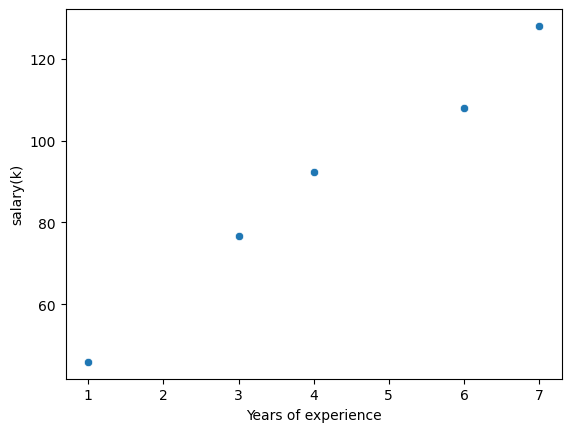

In [21]:
sns.scatterplot(x=x[:,0:1].ravel(), y = y)
plt.xlabel('Years of experience')
plt.ylabel('salary(k)')
plt.show()

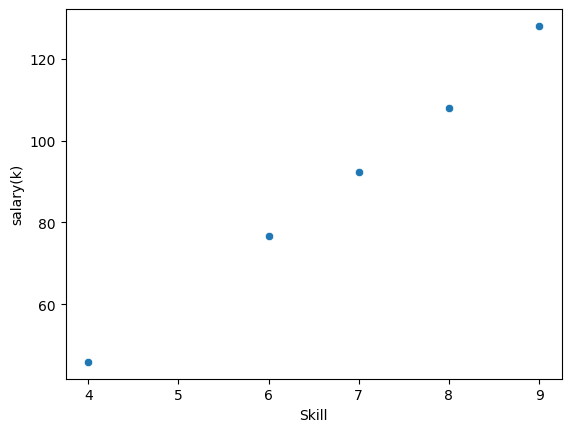

In [22]:
sns.scatterplot(x=x[:,1:2].ravel(), y = y)
plt.xlabel('Skill')
plt.ylabel('salary(k)')
plt.show()

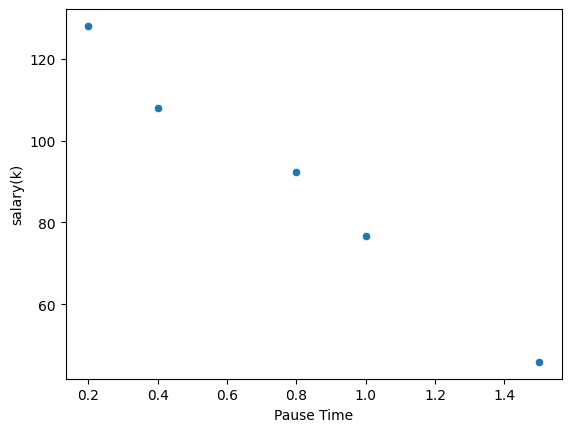

In [23]:
sns.scatterplot(x=x[:,2:3].ravel(), y = y)
plt.xlabel('Pause Time')
plt.ylabel('salary(k)')
plt.show()

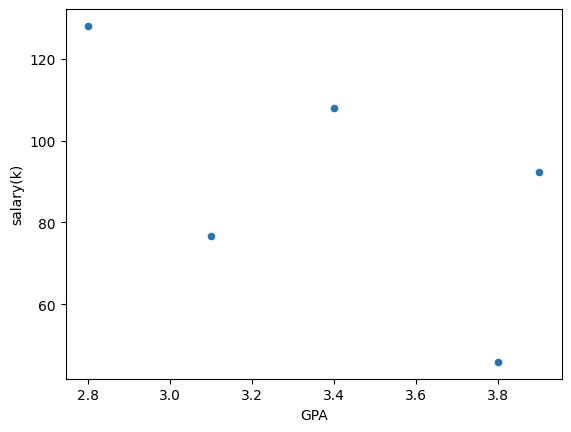

In [24]:
sns.scatterplot(x=x[:,3:].ravel(), y = y)
plt.xlabel('GPA')
plt.ylabel('salary(k)')
plt.show()

In [25]:
def make_prediction(x,y,w,b):
  m = x.shape[0]
  pred_list = np.zeros((m,))

  for i in range(m):
    pred_list[i] = np.dot(w,x[i]) + b

  return pred_list



In [26]:
m = x.shape[0]
n = x.shape[1]

w_init = np.ones((n,))
b = 1.0

make_prediction(x,y,w_init,b)

array([11.3, 14.1, 16.7, 18.8, 20. ])

In [39]:
def compute_cost(x,y,w,b):
  m = x.shape[0]
  cost = 0.0

  pred_list = make_prediction(x,y,w,b)

  error = pred_list - y
  error_squared = error ** 2

  cost = np.sum(error_squared) / (2 * m)

  return cost

In [28]:
w = np.ones((n,))
b = 1.0

compute_cost(x,y,w,b)

[11.3 14.1 16.7 18.8 20. ]
[ -34.6   -62.45  -75.65  -89.1  -108.  ]


np.float64(3042.2895)

In [29]:
def calculate_gradient(x,y,w,b):
  m = x.shape[0]
  n = x.shape[1]

  dj_dw = np.zeros((n,)) #column number = weight
  dj_db = 0.0

  for i in range(m):

    prediction = np.dot(w,x[i]) + b
    error = prediction - y[i]

    for j in range(n):
      dj_dw[j] = dj_dw[j] + (error * x[i,j])

    dj_db = dj_db + error

  return dj_dw/m, dj_db/m




In [30]:
w = np.ones((n,))
b = 1.0
calculate_gradient(x,y,w,b)



(array([-363.03 , -545.49 ,  -46.422, -245.09 ]),
 np.float64(-73.96000000000001))

In [37]:
def gradient_descent(x,y,w,b,max_iter, alpha = 0.01):

  cost_memo = []
  iteration = []

  for i in range(max_iter):
    dj_dw, dj_db = calculate_gradient(x,y,w,b)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    cost = compute_cost(x,y,w,b)
    cost_memo.append(cost)
    iteration.append(i)

    if i % 100 == 0:
      print(f"iteration {i}: cost {cost:0.4f}, dj_dw: {dj_dw}, dj_db: {dj_db} w: {w}, b: {b:0.4f}")

  return w,b,cost_memo, iteration





In [41]:
w = np.zeros((n,))
b = 0.0
w_final,bias, cost_memo, iter_list = gradient_descent(x,y,w = w, b = b, max_iter = 1000, alpha = 0.01)

iteration 0: cost 153.0196, dj_dw: [-437.67  -660.91   -57.608 -299.43 ], dj_db: -90.14 w: [4.3767  6.6091  0.57608 2.9943 ], b: 0.9014
iteration 100: cost 2.5426, dj_dw: [-0.05997115 -0.21817643  0.10593178  0.52423075], dj_db: 0.04595661286515025 w: [ 6.53913253  8.21147644 -0.12445431  1.82617381], b: 0.7699
iteration 200: cost 2.3662, dj_dw: [ 0.17854419 -0.22024124 -0.04420271  0.23623087], dj_db: -0.012328894016123115 w: [ 6.42741394  8.43324419 -0.12251518  1.50471539], b: 0.7659
iteration 300: cost 2.2350, dj_dw: [ 0.18518313 -0.2110662  -0.04927625  0.20831857], dj_db: -0.013838417909441602 w: [ 6.2424145   8.64896996 -0.07380825  1.28613096], b: 0.7798
iteration 400: cost 2.1161, dj_dw: [ 0.1780131  -0.20164836 -0.04569612  0.19682382], dj_db: -0.011985428530188358 w: [ 6.06069306  8.85525122 -0.0262391   1.08387556], b: 0.7927
iteration 500: cost 2.0082, dj_dw: [ 0.17035698 -0.19263891 -0.04179656  0.18681444], dj_db: -0.010032177946486342 w: [5.88656572 9.05231364 0.0174768

In [33]:
print(w_final)
print(bias)

[5.12324196 9.91229202 0.18247577 0.07140468]
0.8319903228829668


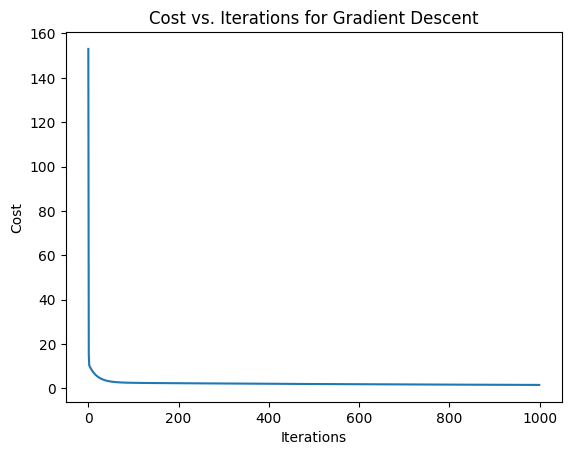

In [40]:
plt.plot(iter_list, cost_memo)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost vs. Iterations for Gradient Descent')
plt.show()